# Lab — Outliers

![Outlier meme](https://raw.githubusercontent.com/dcai-course/assets/master/outlier-meme.jpg)

You are given a clean dataset consisting of many pictures of dogs (the data distribution), and an evaluation dataset that contains outliers (dogs mixed with non-dogs). Your task is to implement and compare various methods for detecting outliers (strictly speaking, this is an anomaly detection task, because you're given a clean training set). You may implement some of the ideas presented in today's lecture, or you can look up other outlier detection algorithms in the linked references or online.

## Install dependencies

If you don't have them installed already, run the following cell.

In [ ]:
!pip install Pillow matplotlib numpy scikit-learn tqdm

## Download and extract the dataset

We're working with a ~ 1.3 GB image dataset in this lab. Either download and extract it manually, or run the following cells.

In [2]:
!wget -nc https://github.com/dcai-course/dcai-lab/releases/download/v0.0.0/outliers.tar.gz
!tar xzf outliers.tar.gz

--2026-01-08 16:03:31--  https://github.com/dcai-course/dcai-lab/releases/download/v0.0.0/outliers.tar.gz
Resolving github.com (github.com)... 140.82.121.4
Connecting to github.com (github.com)|140.82.121.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/574646981/eb9a02c1-2b83-421e-88ae-b94573fd58b2?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-01-08T15%3A00%3A07Z&rscd=attachment%3B+filename%3Doutliers.tar.gz&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-01-08T14%3A00%3A07Z&ske=2026-01-08T15%3A00%3A07Z&sks=b&skv=2018-11-09&sig=7qgYNHswKNx8mYyWtV%2FWuqn61iQGiSvhNNdH1upc8rQ%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc2Nzg4NDYxMiwibmJmIjoxNzY3ODgxMDEyLCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5

## Visualize some of the data

In [5]:
import os
import numpy as np
from tqdm import tqdm

train_files = sorted([os.path.join('train', i) for i in os.listdir('train') if i.endswith('.JPEG')])
test_files = sorted([os.path.join('test', i) for i in os.listdir('test') if i.endswith('.JPEG')])
np.random.seed(1337) # for reproducibility
np.random.shuffle(train_files)
np.random.shuffle(test_files)
# ground truth, used for evaluation of your outlier detection implementation
with open('outliers_ground_truth.txt') as f:
    test_outliers = [os.path.join('test', i) for i in f.read().strip().split('\n')]
    test_outliers_mask = np.array([i in test_outliers for i in test_files])

In [4]:
import matplotlib.pyplot as plt
import PIL

def plot_images(paths, per_row=5):
    '''
    Visualize images by their paths.
    
    Shows whether an image is an outlier or not, using the ground-truth information.
    '''
    n = len(paths)
    cols = per_row
    rows = n // per_row
    plt.rcParams["figure.figsize"] = (15,4*rows)
    for i, path in enumerate(paths):
        ax = plt.subplot(rows, cols, i+1)
        img = PIL.Image.open(path)
        img = np.asarray(img)
        ax.imshow(img)
        if path in test_outliers:
            ax.set_title('outlier')
        ax.axis('off')
    plt.show()

First, let's visualize the training distribution:

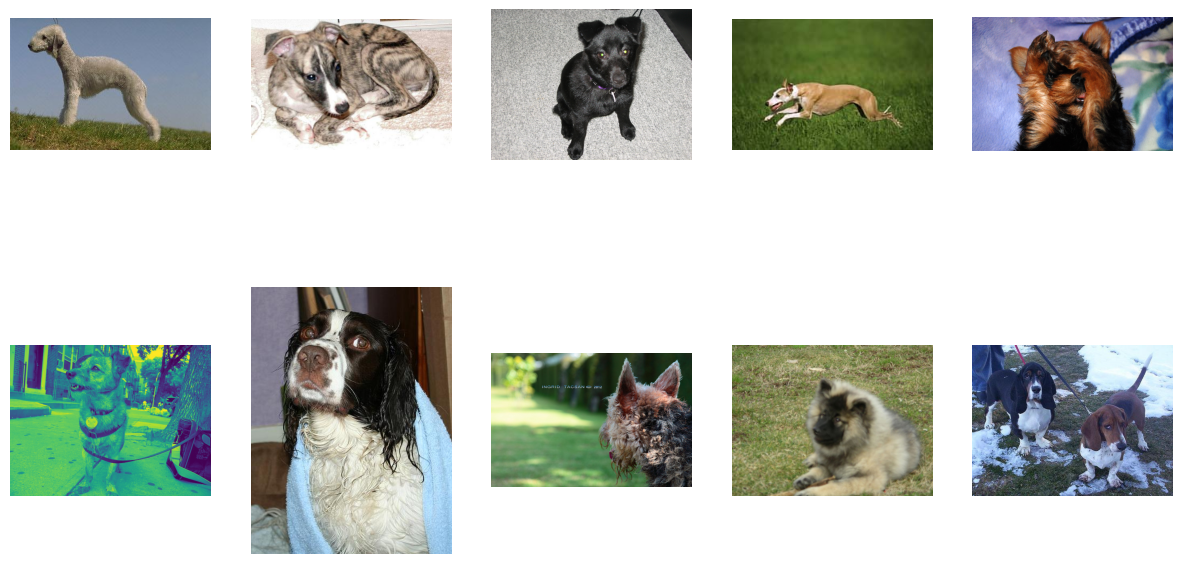

In [3]:
plot_images(train_files[10:20])

Now, let's visualize the test distribution (which contains some outliers). The visualization code uses the ground-truth information to label outliers. Our goal in this lab is to find these outliers automatically.

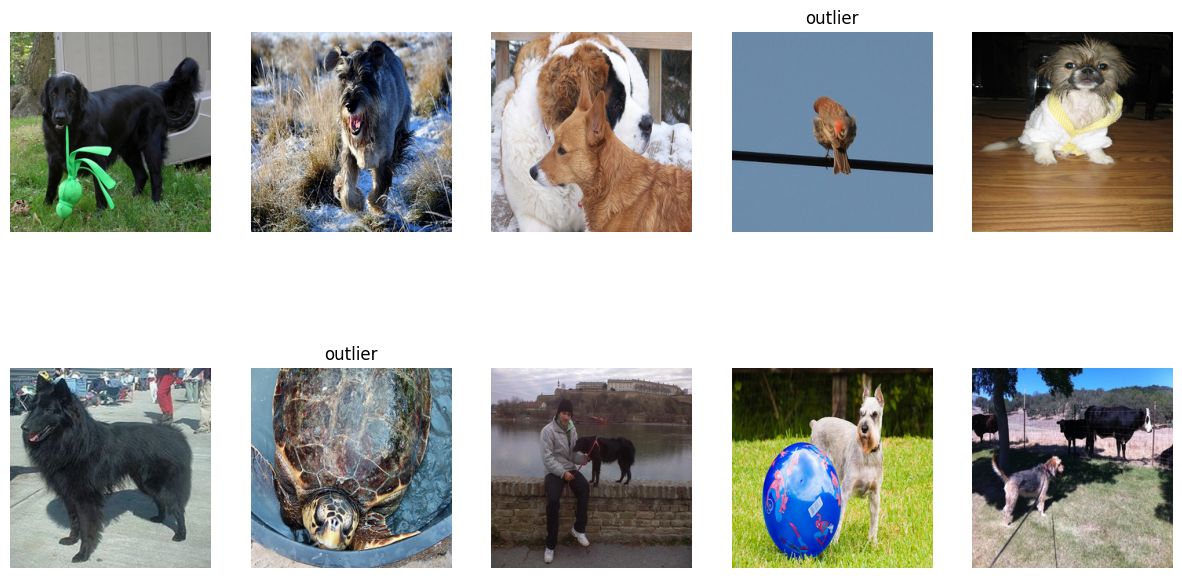

In [88]:
plot_images(test_files[0:10])

## Evaluation metrics

Most methods we implement will assign as score to every datapoint, and we'll have to choose a threshold to decide which data points we consider outliers. To evaluate such methods, we can look at an ROC curve (true positive rate vs false positive rate), and if we want a single summary number, look at the AUROC (area under the ROC curve).

Here, we define some utilities to plot ROC curves for you.

In [3]:
from sklearn import metrics
import warnings
def plot_roc(*scores_and_names):
    '''
    Plots an ROC curve and computes AUC, given a list of scores and method names.
    
    Call this function like plot_roc(scores1, 'name of method 1', scores2, 'name of method 2', ...)
    to compare different outlier detection methods.
    '''
    fpr = []
    tpr = []
    for score, name in zip(scores_and_names[::2], scores_and_names[1::2]):
        fpr, tpr, auc = None, None, None
        if len(score) != len(test_outliers_mask):
            warnings.warn("The lengths don't match, truncate")
            minlen = min(len(score), len(test_outliers_mask))
            print(test_outliers_mask)
            fpr, tpr, _ = metrics.roc_curve(test_outliers_mask[:minlen], score[:minlen])
            auc = metrics.roc_auc_score(test_outliers_mask[:minlen], score[:minlen])
        else:
            fpr, tpr, _ = metrics.roc_curve(test_outliers_mask, score)
            auc = metrics.roc_auc_score(test_outliers_mask, score)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.2f})')
    plt.legend(loc=0)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')

## Baseline methods

Here, we implement a couple really simple methods, just to show you how the pieces fit together. You can do a _lot_ better than these.

We want to compute a score for each datapoint that indicates how likely it is (compared to the others) to be an outlier (in this lab, these scores do not need to be calibrated as anything like probabilities, they just need to be meaningful relative to each other). The score for a datapoint is calculated based on the test image and features of the train distribution, but _not_ taking into account other datapoints in the test set or information on which other images in the test set are outliers or not.

### Random scores

The most basic baseline: assign each datapoint a random score.

Check yourself: what do you expect the ROC curve to look like, and what will be the AUC? Does this depend on what fraction of the dataset are outliers?

In [71]:
np.random.seed(1234)
random_ood_scores = np.random.uniform(size=len(test_files))

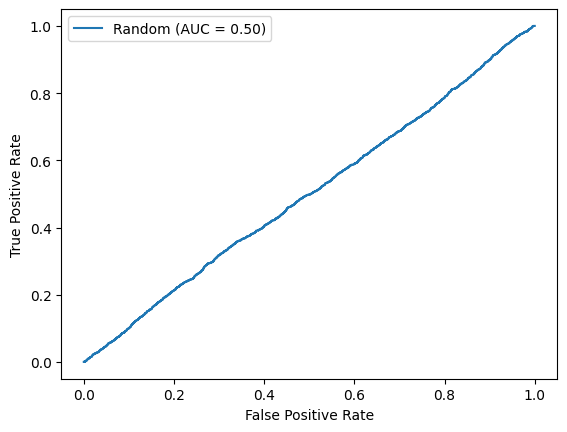

In [72]:
plot_roc(random_ood_scores, 'Random')

### Average color

As a really simple score, we can compute the average color of in-distribution images, and for a new image, compute its score as the difference between its average color and the average color of training images.

In [73]:
train_mean_pixel = np.zeros(3)
for path in tqdm(train_files):
    train_mean_pixel += np.asarray(PIL.Image.open(path).convert('RGB')).mean(axis=(0, 1))
train_mean_pixel /= len(train_files)

100%|██████████| 10030/10030 [01:33<00:00, 107.27it/s]


In [74]:
mean_pixel_ood_scores = []
for path in tqdm(test_files):
    img_mean_pixel = np.asarray(PIL.Image.open(path).convert('RGB')).mean(axis=(0, 1))
    diff = np.sum(np.abs(img_mean_pixel - train_mean_pixel))
    mean_pixel_ood_scores.append(diff)
mean_pixel_ood_scores = np.array(mean_pixel_ood_scores)

100%|██████████| 8546/8546 [01:11<00:00, 119.17it/s]


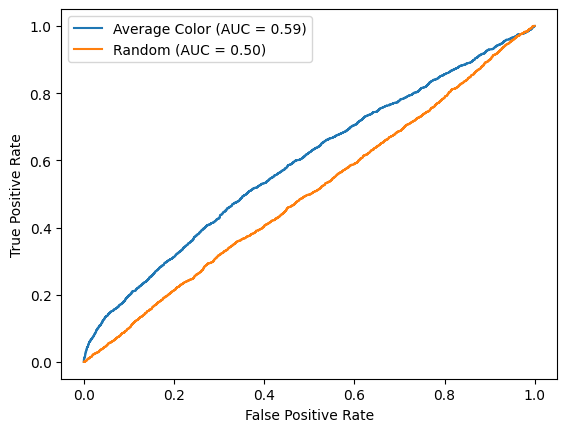

In [75]:
plot_roc(mean_pixel_ood_scores, 'Average Color', random_ood_scores, 'Random')

### KNN in image space, on resized images

It's not sensible to do KNN in image space, because the images are really large. But we can try resizing them to some fixed size, like 32x32, and doing KNN with L2 distance in that space.

In [ ]:
!pip install cleanlab

In [76]:
train_tiny_image_reps = []
for path in tqdm(train_files):
    train_tiny_image_reps.append(np.asarray(PIL.Image.open(path).convert('RGB').resize((32, 32))).flatten())
train_tiny_image_reps = np.stack(train_tiny_image_reps)

100%|██████████| 10030/10030 [00:30<00:00, 331.10it/s]


In [77]:
test_tiny_image_reps = []
for path in tqdm(test_files):
    test_tiny_image_reps.append(np.asarray(PIL.Image.open(path).convert('RGB').resize((32, 32))).flatten())
test_tiny_image_reps = np.stack(test_tiny_image_reps)

100%|██████████| 8546/8546 [00:14<00:00, 580.36it/s]


In [78]:
from cleanlab.outlier import OutOfDistribution

tiny_ood = OutOfDistribution()
tiny_ood.fit(features=train_tiny_image_reps)
tiny_ood_scores = -tiny_ood.score(features=test_tiny_image_reps)

/Users/vaiyr630/.pyenv/versions/torch-tf/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Fitting OOD estimator based on provided features ...


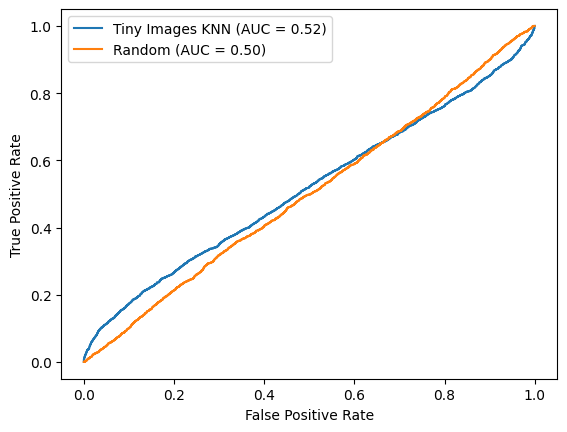

In [79]:
plot_roc(tiny_ood_scores, 'Tiny Images KNN', random_ood_scores, 'Random')

### Isolation forest on image histograms

It's not sensible to use the isolation forest algorithm directly on the high-dimensional image data, but we can try it on features computed from the image. Here, we compute image histograms as features.

In [80]:
def compute_histograms(paths):
    all_hists = []
    for path in tqdm(paths):
        x = np.asarray(PIL.Image.open(path).convert('RGB').resize((256, 256)))
        hists = []
        for c in range(3):
            hist, _ = np.histogram(x[:,:,c], bins=32, range=(0, 256))
            hists.append(hist)
        hist = np.concatenate(hists)
        all_hists.append(hist)
    return np.stack(all_hists)

In [81]:
train_histograms = compute_histograms(train_files)

100%|██████████| 10030/10030 [00:51<00:00, 196.40it/s]


In [82]:
test_histograms = compute_histograms(test_files)

100%|██████████| 8546/8546 [00:26<00:00, 322.12it/s]


In [83]:
from sklearn.ensemble import IsolationForest

isolation_forest = IsolationForest(random_state=42)
isolation_forest.fit(train_histograms)

isolation_scores = -isolation_forest.score_samples(test_histograms) # negate, so higher score = more abnormal

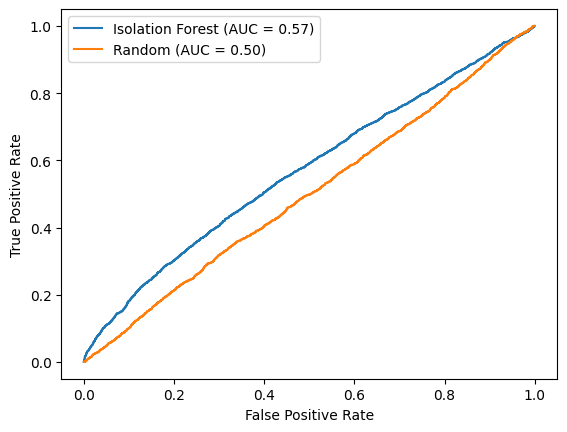

In [84]:
plot_roc(isolation_scores, 'Isolation Forest', random_ood_scores, 'Random')

### Comparing the (very simple) methods we implemented

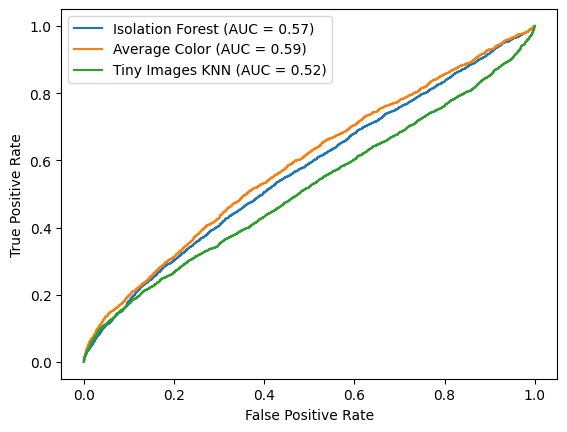

In [85]:
plot_roc(isolation_scores, 'Isolation Forest', mean_pixel_ood_scores, 'Average Color', tiny_ood_scores, 'Tiny Images KNN')

## Exercise: implement and compare outlier detection methods

Implement and compare various methods for outlier detection to find outliers in the test set (`test_files`). Ground-truth information, used for evaluating your outlier detection algorithm, is in `test_outliers` / `test_outliers_mask`.

You should compute a score for each datapoint.  The scores should be computed based as a function of each test image (that may depend on statistics of the training data), but not any information about the other test images or which test examples are outliers or not. That means, for example, that you can't train a binary classifier on whether an image is in-distribution or out-of-distribution by using the outlier images and "labels" in `test_outliers` (that is only for evaluation). The scenario is that you've been able to train on the train distribution, and then an anomaly detection system is deployed "live", where it handles one datapoint that it sees at a time (and never gets ground-truth information on whether that datapoint was an outlier).

We want scores to take higher values for test images which are actually outliers vs those which are not.

As one of the methods you implement, we suggest using embeddings from a pre-trained model and using KNN distance as a score. A good place to find pre-trained models is [HuggingFace](https://huggingface.co/models). Another good place to look is the timm library; here is a [tutorial on feature extraction](https://huggingface.co/docs/timm/feature_extraction). You can find a list of timm models [here](https://huggingface.co/docs/timm/models).

Another idea is to train an autoencoder and use reconstruction loss as a score. You might find [this tutorial](https://towardsdatascience.com/simplifing-image-outlier-detection-with-alibi-detect-6aea686bf7ba) helpful.

You should be able to get to AUROC > 0.95.

The dataset used in this lab is taken from ImageNet (train data comes from the ImageNet train set, and test data comes from the ImageNet validation set). Many pre-trained models available online are trained on ImageNet. How does this help explain the great performance of the pre-trained model + KNN distance method?

After implementing a couple different methods, compare them using `plot_roc`.

Also, you might find it interesting to qualitiatively evaluate your outlier detection implementations. Plot the highest-scoring images and the lowest-scoring images using `plot_images`.

In [ ]:
# YOUR CODE HERE

## Image embeddings + KNN

For the first method, I implement the KNN-based outlier detection method using CLIP image embeddings as the features.

In [ ]:
# Load the model
from transformers import CLIPModel, CLIPProcessor
clip_model = CLIPModel.from_pretrained('openai/clip-vit-large-patch14')

In [ ]:
import torch
from torchvision.transforms import Compose, Resize, CenterCrop, ToTensor, Normalize
from PIL import Image

image_processor = Compose([
    Resize(size=224, interpolation=Image.BICUBIC),
    CenterCrop(size=(224, 224)),
    lambda img: img.convert('RGB'),
    ToTensor(),
    Normalize(mean=(0.48145466, 0.4578275, 0.40821073), std=(0.26862954, 0.26130258, 0.27577711))
])

def get_embeddings(img):
    inputs=dict(pixel_values=image_processor(img).unsqueeze(0))
    with torch.no_grad():
        vision_outputs = clip_model.vision_model(**inputs)
        image_embeds = vision_outputs[1]
        image_embeds = clip_model.visual_projection(image_embeds)
        image_embeds = image_embeds / image_embeds.norm(dim=-1, keepdim=True)
    return image_embeds

# Batched implementation; seems to save 30% time which is frankly not that much
def get_multiple_embeddings(imgs):
    imglist = torch.concat([image_processor(img).unsqueeze(0) for img in imgs])
    inputs=dict(pixel_values=imglist)
    with torch.no_grad():
        vision_outputs = clip_model.vision_model(**inputs)
        image_embeds = vision_outputs[1]
        image_embeds = clip_model.visual_projection(image_embeds)
        image_embeds = image_embeds / image_embeds.norm(dim=-1, keepdim=True)
    return image_embeds



In [112]:
# Number of training examples; since the method is so simple and
# the embeddings so rich, this can be quite low
N_embedding = 100
imgs = [PIL.Image.open(f) for f in train_files[:N_embedding]]
train_embedding_reps = get_multiple_embeddings(imgs)

In [110]:
# Running CLIP is so slow that I implemented it batched
# for a subset of the data.

batch_size = 20
test_size = 5000
test_embedding_reps = []
for ix in tqdm(range(0, min(len(test_files), test_size), batch_size)):
    paths = test_files[ix:min(ix+batch_size, test_size)] # min(len(test_files), test_size)
    imgs = [PIL.Image.open(f) for f in paths]
    emb_path = get_multiple_embeddings(imgs)
    test_embedding_reps.append(emb_path)
test_embedding_reps = torch.concat(test_embedding_reps)
test_embedding_reps.shape

100%|██████████| 250/250 [21:28<00:00,  5.15s/it]


torch.Size([5000, 768])

Fitting OOD estimator based on provided features ...
[False False False ...  True False False]
[False False False ...  True False False]


/var/folders/k4/rg9x3ybs4k93y84sqfbyc0zh0000gn/T/ipykernel_36295/1714349911.py:15: UserWarning: The lengths don't match, truncate
  warnings.warn("The lengths don't match, truncate")
/var/folders/k4/rg9x3ybs4k93y84sqfbyc0zh0000gn/T/ipykernel_36295/1714349911.py:15: UserWarning: The lengths don't match, truncate
  warnings.warn("The lengths don't match, truncate")


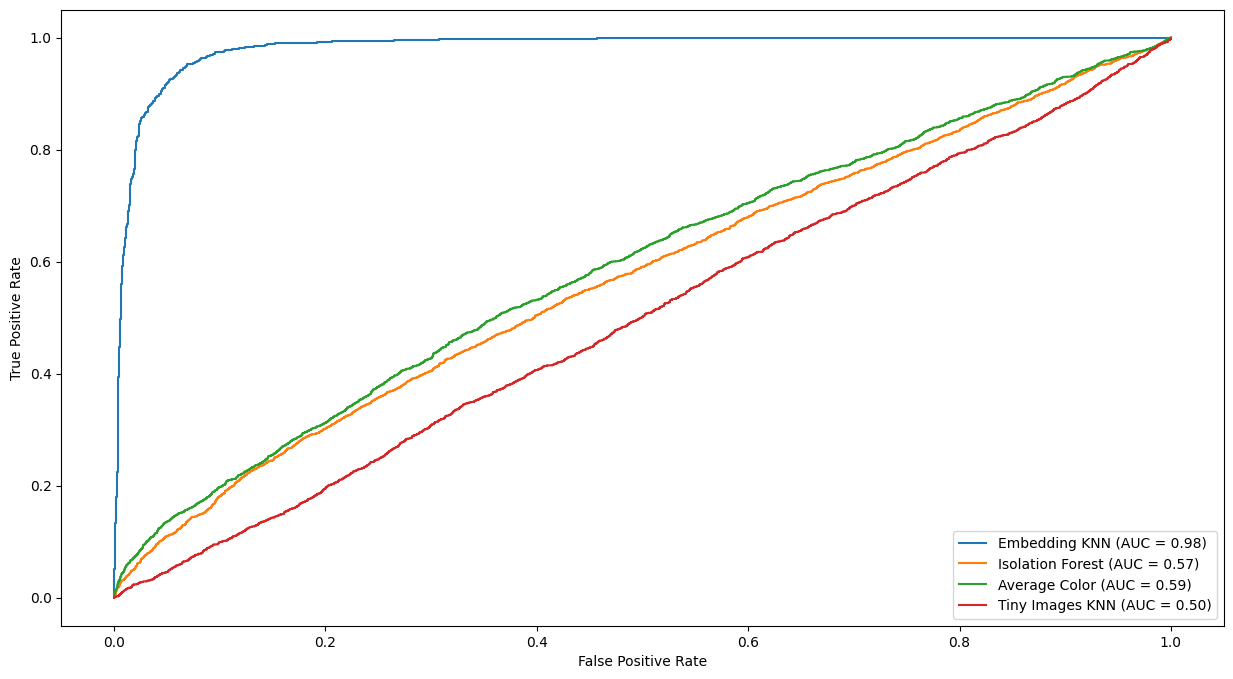

In [111]:
from cleanlab.outlier import OutOfDistribution

embedding_ood = OutOfDistribution()
embedding_ood.fit(features=train_embedding_reps)
embedding_ood_scores = -embedding_ood.score(features=test_embedding_reps)
embedding_ood_scores
plot_roc(embedding_ood_scores, 'Embedding KNN', isolation_scores, 'Isolation Forest', mean_pixel_ood_scores, 'Average Color', tiny_ood_scores, 'Tiny Images KNN')

Bottom line: AUC 0.98 is way higher than any of the simplistic baselines, and higher than the 0.95 target.

## Autoencoder outlier detection

Some image size standardization might be needed.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, losses
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model

/Users/vaiyr630/.pyenv/versions/torch-tf/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


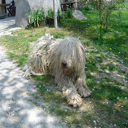

In [9]:
# Check that the image size is reasonable
IMG_SIZE = 128
PIL.Image.open(train_files[400]).resize((IMG_SIZE, IMG_SIZE))

In [35]:
train_n = 11000
train_autoencoder = []
for f in tqdm(train_files[:train_n]):
    x_i = np.asarray(PIL.Image.open(f).resize((IMG_SIZE, IMG_SIZE)).convert('RGB')) / 256.0
    #print(x_i.shape)
    train_autoencoder.append(x_i)
    
train_autoencoder = np.stack(train_autoencoder)
train_autoencoder.shape

100%|██████████| 10030/10030 [01:00<00:00, 166.94it/s]


(10030, 128, 128, 3)

In [37]:
test_n = 3000
test_autoencoder = []
for f in tqdm(test_files[:test_n]):
    x_i = np.asarray(PIL.Image.open(f).resize((IMG_SIZE, IMG_SIZE)).convert('RGB')) / 256.0
    #print(x_i.shape)
    test_autoencoder.append(x_i)
    
test_autoencoder = np.stack(test_autoencoder)
test_autoencoder.shape

100%|██████████| 3000/3000 [00:15<00:00, 197.34it/s]


(3000, 128, 128, 3)

In [38]:
class Autoencoder(Model):
  def __init__(self, latent_dim, shape):
    super(Autoencoder, self).__init__()
    self.latent_dim = latent_dim
    self.shape = shape
    self.encoder = tf.keras.Sequential([
      layers.Flatten(),
      layers.Dense(latent_dim, activation='relu'),
      layers.Dense(latent_dim, activation='relu'),
      #layers.Dense(latent_dim, activation='relu'),
    ])
    self.decoder = tf.keras.Sequential([
      layers.Dense(int(tf.math.reduce_prod(shape).numpy()), activation='sigmoid'),
      layers.Reshape(shape)
    ])

  def call(self, x):
    encoded = self.encoder(x)
    decoded = self.decoder(encoded)
    return decoded

In [39]:
shape = np.array(train_autoencoder.shape[1:])
latent_dim = 256
print(shape, type(shape))
autoencoder = Autoencoder(latent_dim, shape)
autoencoder.compile(optimizer='adam', loss=losses.MeanSquaredError())

[128 128   3] <class 'numpy.ndarray'>


In [40]:
autoencoder.fit(train_autoencoder, train_autoencoder,
                epochs=5,
                shuffle=True,
                validation_data=(test_autoencoder,test_autoencoder))

Epoch 1/5
314/314 ━━━━━━━━━━━━━━━━━━━━ 35s 104ms/step - loss: 0.0479 - val_loss: 0.0420
Epoch 2/5
314/314 ━━━━━━━━━━━━━━━━━━━━ 27s 87ms/step - loss: 0.0407 - val_loss: 0.0398
Epoch 3/5
314/314 ━━━━━━━━━━━━━━━━━━━━ 27s 87ms/step - loss: 0.0386 - val_loss: 0.0382
Epoch 4/5
314/314 ━━━━━━━━━━━━━━━━━━━━ 28s 89ms/step - loss: 0.0370 - val_loss: 0.0370
Epoch 5/5
314/314 ━━━━━━━━━━━━━━━━━━━━ 28s 89ms/step - loss: 0.0356 - val_loss: 0.0362


94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


/var/folders/k4/rg9x3ybs4k93y84sqfbyc0zh0000gn/T/ipykernel_14450/1714349911.py:15: UserWarning: The lengths don't match, truncate
  warnings.warn("The lengths don't match, truncate")


[False False False ...  True False False]


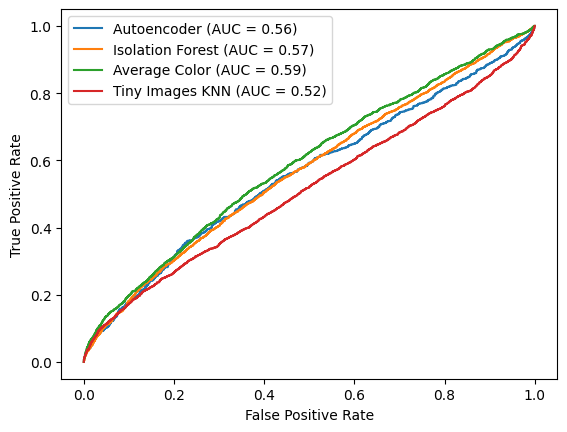

In [86]:
test_predictions = autoencoder.predict(test_autoencoder) 
test_deltas = test_predictions - test_autoencoder
test_deltas2 = tf.multiply(test_deltas, test_deltas)
autoencoder_scores = tf.reduce_sum(tf.reduce_sum(tf.reduce_sum(test_deltas2, axis=-1), axis=-1), axis=-1)
plot_roc(autoencoder_scores, 'Autoencoder', isolation_scores, 'Isolation Forest', mean_pixel_ood_scores, 'Average Color', tiny_ood_scores, 'Tiny Images KNN')

This generates a better-than-random AUC, however, a far cry from the embedding and losing to some of the simplistic baselines. This is probably due to the autoencoder being very simplistic, and not really recreating the dogs that well. Let's investigate that.

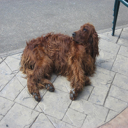

In [87]:
PIL.Image.open(test_files[402]).resize((IMG_SIZE, IMG_SIZE))

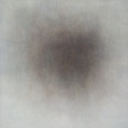

In [88]:
pred_402 = np.uint8(np.array(test_predictions[402]) * 256)
PIL.Image.fromarray(pred_402)
#pred_402

Admittedly, not the best reconstruction of the image. But manages to recreate a very blurry version of the image with roughly the same dog and background colors.